<a href="https://colab.research.google.com/github/PedrodCast/Multidimensional_Scaling_Word_Embbeding/blob/main/Multidimensional_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementação e exemplo de uso do Multidimensional Scaling (MDS)
Nome: Pedro de Carvalho Castanheira

## Pacotes


Os pacotes `PythonCall`, `CondaPkg`, `huggingface_hub` e `safetensors` são necessários para importar os datasets que serão utilizados no exemplo de uso do algoritmo.

In [ ]:
import Pkg;
Pkg.add("PythonCall")
Pkg.add("CondaPkg")
using CondaPkg
CondaPkg.add("huggingface_hub")
CondaPkg.add("safetensors")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed UnsafePointers ─ v1.0.0
   Installed micromamba_jll ─ v2.3.1+0
   Installed pixi_jll ─────── v0.63.2+0
   Installed CondaPkg ─────── v0.2.36
   Installed PythonCall ───── v0.9.35
   Installed Pidfile ──────── v1.3.0
   Installed MicroMamba ───── v0.1.15
    Updating `~/.julia/environments/v1.12/Project.toml`
  [6099a3de] + PythonCall v0.9.35
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [992eb4ea] + CondaPkg v0.2.36
  [0b3b1443] + MicroMamba v0.1.15
  [fa939f87] + Pidfile v1.3.0
  [6099a3de] + PythonCall v0.9.35
  [e17b2a0c] + UnsafePointers v1.0.0
  [f8abcde7] + micromamba_jll v2.3.1+0
  [4d7b5844] + pixi_jll v0.63.2+0
Precompiling packages...
   3509.6 ms  ✓ UnsafePointers
   2814.4 ms  ✓ Pidfile
   3418.1 ms  ✓ micromamba_jll
   1978.6 ms  ✓ pixi_jll
   2945.5 ms  ✓ MicroMamba
   5087.6 ms  ✓ CondaPkg
  39012.4 ms  ✓ PythonCall
IJulia → IJuliaPythonCallExt Waiting f

In [ ]:
using LinearAlgebra
using Plots
using PythonCall

In [ ]:
hf = pyimport("huggingface_hub")
np = pyimport("numpy")
st = pyimport("safetensors.numpy")

Python: <module 'safetensors.numpy' from '/root/.julia/environments/v1.12/.CondaPkg/.pixi/envs/default/lib/python3.12/site-packages/safetensors/numpy.py'>

## Implementações

### Implementando a matriz de distâncias

`matriz_distancias(X, dist)`-> `X` é a matriz de coordenadas dos pontos, `dist` é a função que calcula a distância entre os pontos.

A função matriz_distancias recebe como argumento uma matriz X que contém a configuração dos n pontos (cada linha contem as coordenadas de um ponto), e retorna uma matriz de distâncias M onde cada elemento Mᵢⱼ corresponde a distância entre os pontos i e j.

Note que a matriz retornada será simétrica e terá diagonal nula.

Além disso, a função também recebe como argumento uma função que calcula a distância utilizada na matriz. Por padrão, se o argumento não for passado, é utilizada a distância euclidiana.

In [ ]:
function d_euclidiana(a, b) # Distância euclidiana
  return norm(a - b)
end

function d_manhattan(a, b) # Distância manhattan
  return sum(abs.(a - b))
end

function d_cos(a, b) # Distância de Cosseno
  return 1 - (dot(a, b)/(norm(a) * norm(b)))
end

d_cos (generic function with 1 method)

In [ ]:
function matriz_distancias(X, dist=d_euclidiana)
 n = size(X, 1)
  M = zeros(n, n)
  for i in 1:n
    for j in 1:n
      M[i, j] = dist(X[i, :], X[j, :])
    end
  end
  return M
end

matriz_distancias (generic function with 2 methods)

### Implementação do MDS Clássico

`MDSC(D, k)` -> MDS Clássico, `D` é a matriz de distâncias e `k` é a quantidade de dimensões da matriz resultante.

In [ ]:
  function MDSC(D, k = 2)
    n = size(D, 1)
    H = I - ones(n,n) / n

    Bx = -(1/2) .* (H * D.^2 * H)

    U, S, V = svd(Bx)


    Sk = Diagonal(S[1:k])
    Uk = U[:, 1:k]


    Y = Uk * Sk.^(1/2)
    return Y
  end

MDSC (generic function with 2 methods)

A função MDSC implementa o MDS clássico, que tem resposta fechada.

Recebe como argumento uma matriz de Distâncias e a dimensão k das coordenadas retornadas

### Implementando stress e Gutmann

`stress(X, D, normal)` -> Retorna o **erro** total (ou relativo) ao quadrado, aceitando como argumento a configuração de pontos na matriz `X` e a matriz de dissimilaridades `D`.

OBS: O stress normalizado só é um valor entre 0 e 1 **após a convergência**.

In [ ]:
function stress(X, D, normal=false)
  n = size(D, 1)
  D_aprox = matriz_distancias(X)

  bruto = sum((D_aprox[i, j] - D[i, j])^2 for i in 1:n for j in (i+1):n)
  if normal # O stress normalizado é um valor entre 0 e 1
    return sqrt(bruto / sum(D_aprox[i,j]^2 for i in 1:n for j in (i+1):n))
  else
    return bruto
  end
end

stress (generic function with 2 methods)

In [ ]:
function guttman(Z, D)
  n = size(D, 1)
  D_aprox = matriz_distancias(Z)

  B = zeros(n, n)
  for i in 1:n
    for j in 1:n
      if i==j
        continue
      elseif D_aprox[i, j] > 1e-10 # D_aprox[i,j] != 0
        B[i, j] = -D[i,j]/D_aprox[i,j]
      else
        B[i,j] = 0
      end
    end
  end
  for i in 1:n
    B[i, i] = -sum(B[i,j] for j in 1:n)
  end

  return (B * Z)/n
end

guttman (generic function with 1 method)

### Implementando o MDS iterativo
`MDSI(D, k)` -> MDS Iterativo, `D` é a matriz de distâncias e `k` é a quantidade de dimensões da matriz resultante.

In [ ]:
function MDSI(D, k=2) # MDS Iterativo
  n = size(D, 1)

  X0 = MDSC(D, k) # Configuração inicial
  Z = X0
  i = 0
  e = 1e-6

  s1 = stress(X0, D)
  s0 = s1

  Xi = X0
  while i==0 || (s0 - s1 > e && i <= 100)
    s0 = s1
    i += 1

    Xi = guttman(Z, D)
    s1 = stress(Xi, D)
    Z = Xi
  end
  return Xi
end

MDSI (generic function with 2 methods)

A função MDSI implementa o MDS Métrico, que utiliza um algoritmo iterativo para minimizar a função 'stress' (erro) e se aproximar do conjunto de pontos que melhor representa as distâncias originais.

Os argumentos são os mesmos da função MDSC.

## Carregando o dataset
`vec` -> matriz de embedding (929606×50)

`vocab`-> vetor de palavras

O dataset utilizado pode ser encontrado em: [huggingface.co](https://huggingface.co/nilc-nlp/word2vec-cbow-50d)

O código utilizado para carregá-lo está disponível no site, eu apenas adaptei ele para a linguagem Julia pois ele é originalmente em Python.

In [ ]:
path = hf.hf_hub_download(repo_id="nilc-nlp/word2vec-cbow-50d",
                       filename="embeddings.safetensors")

data = st.load_file(path)
vectors = data["embeddings"]

vocab_path = hf.hf_hub_download(repo_id="nilc-nlp/word2vec-cbow-50d",
                             filename="vocab.txt")

caminho_julia = pyconvert(String, vocab_path)

vocab = readlines(caminho_julia)

vec = pyconvert(Matrix{Float64}, vectors)

findfirst(item->item=="obstante", vocab)

5307

## Aplicando MDS num conjunto de palavras escolhidas

In [ ]:
function plot_sol(Y, t)
  cords_x = Y[:,1]
  cords_y = Y[:,2]

  p = scatter(cords_x, cords_y, color=:black,
            title=t,
            label="",
            xlims = (minimum(cords_x)-0.1, maximum(cords_x)+0.1),
            ylims = (minimum(cords_y)-0.1, maximum(cords_y)+0.1))

  for i in 1:size(Y, 1)
    annotate!(cords_x[i], cords_y[i]+0.1, text(vocab[ind[i]], 8))
  end

  return p
end

plot_sol (generic function with 1 method)

In [ ]:
# Lista de palavras selecionadas
lst=["contaminação", "bactéria", "doença", "comida",
"fruta", "maçã",  "pedro", "carol", "daniel"]

# Índices das palavras
ind = findall(in(lst), vocab)

X = vec[ind,:]

9×50 Matrix{Float64}:
  0.613371   0.103113   0.137707  …  -0.287782  -0.111896  -0.473282
 -0.071968   0.471259   0.259661     -0.35281   -0.201435  -0.234063
  0.338533  -0.040905   0.096305     -0.349479   0.021882  -0.104974
  0.197586  -0.025263   0.043964     -0.281603  -0.448591   0.013926
  0.034315   0.369418   0.18983      -0.30519   -0.255733  -0.427025
 -0.077191  -0.064736  -0.013805  …  -0.176381  -0.119722  -0.061836
 -0.000918   0.330718   0.049803     -0.194659  -0.392749   0.430267
 -0.157214   0.30991    0.234117     -0.3711    -0.460549   0.514232
 -0.083988   0.647852   0.264745     -0.36812   -0.105566   0.450712

Stress da solução: 0.300981940024573

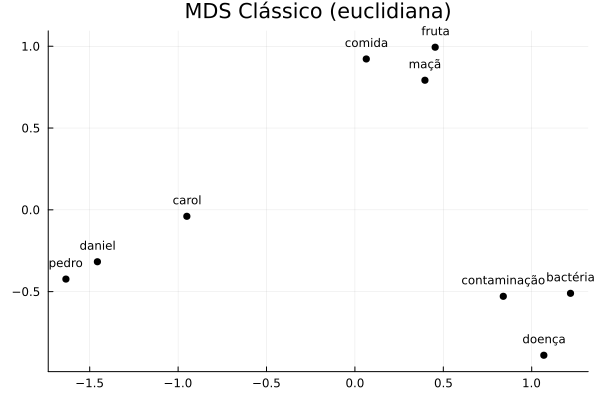


Stress da solução: 0.16414100989247266

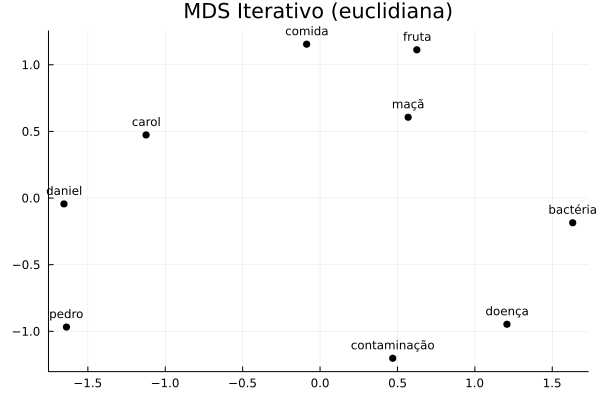

In [ ]:
# Solução utilizando distância euclidiana
D = matriz_distancias(X)

Y1 = MDSC(D)
p1 = plot_sol(Y1, "MDS Clássico (euclidiana)")

Y2 = MDSI(D)
p2 = plot_sol(Y2, "MDS Iterativo (euclidiana)")

print("Stress da solução: ", stress(Y1, D, true))
display(p1)

print("\n")

print("Stress da solução: ", stress(Y2, D, true))
display(p2)

Stress da solução: 0.14160827907685775

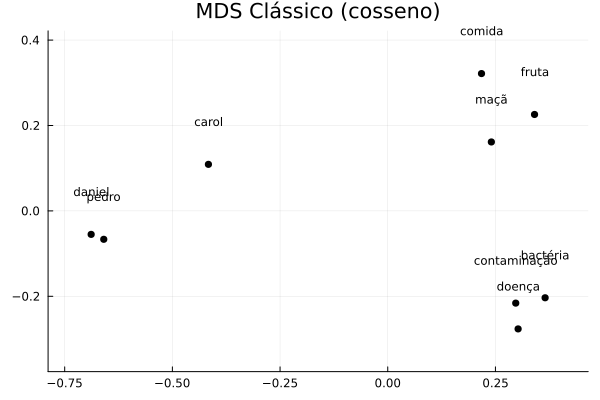


Stress da solução: 0.08726913260164085

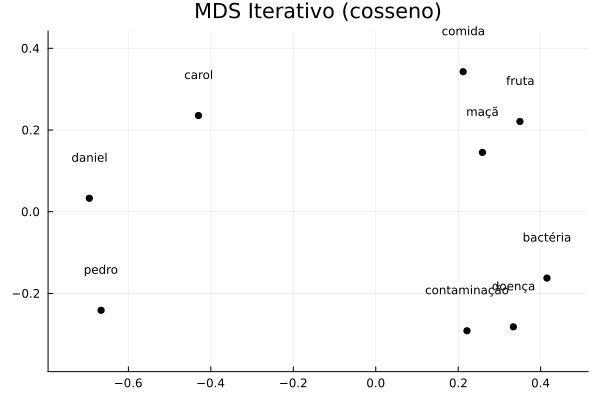

In [ ]:
# Solução utilizando distância de cosseno
D = matriz_distancias(X, d_cos)

Y1 = MDSC(D)
p1 = plot_sol(Y1, "MDS Clássico (cosseno)")

Y2 = MDSI(D)
p2 = plot_sol(Y2, "MDS Iterativo (cosseno)")

print("Stress da solução: ", stress(Y1, D, true))
display(p1)

print("\n")

print("Stress da solução: ", stress(Y2, D, true))
display(p2)